# R09 — [Rebuttal] Extended Task Geometry (multi-bank merge)

**Purpose:** recompute the per-task directional geometry with EVERY valid over-refusal task,
merging all available LLaMA banks: the original 270-sample bank, R01's 4-new-task bank (820
samples), R08's 3-new-task pilot bank (615 samples), and R10's expansion bank (net-new
`train`-split contents, 2,020 samples) -- 3,725 samples and 12 task frames over the full
SafeConstellations dataset.

**What this supersedes / compares against:** R02 computed the same quantities on the 2-bank
merge (original + R01) and produced the numbers previously in the response docs:

| Quantity | R02 value | R09 4-bank run (2026-07-10, final) |
|---|---|---|
| Valid OR tasks (n>=5) | 3 | 6 |
| Per-task OR direction cosine (off-diag) | 0.428 +/- 0.058 | 0.358 +/- 0.235 |
| Fresh per-task RH alignment (same bank) | 0.536 +/- 0.086 (N=4) | 0.636 +/- 0.140 (N=7) |
| cos(global OR dir, Arditi) @ peak | +0.464 | +0.410 |
| mean cos(task OR dir, Arditi) | 0.596 | 0.511 |
| P(n80_OR > n80_RH), matched n | 0.00-0.90% (claim retracted) | 0.00% (consistent) |

R02 is left untouched (its numbers stay valid and citable); this notebook produces the
extended versions with `[R9.x]` tags, plus an explicit decision guide on which set to quote.
The full run satisfied the decision guide's "use extended numbers" branch (6 tasks, OR 0.358
clearly below RH 0.636, a wider contrast than R02's), and the response docs are updated with
these figures, including the full-scale per-task over-refusal rates (see R08/R10 headline
counts for continuation/draft_message/keywords_identification/conversational_qa).

**Honesty rule for using these numbers:** if the extended set strengthens the same
conclusion (more OR tasks, OR still more task-divergent than RH), quote it in the docs in
place of the older version. If it *weakens or reverses* the contrast, do NOT silently keep
quoting the old number while sitting on this analysis -- surface it and decide the framing
honestly (scope the claim, or report both), exactly as was done for the dimensionality
retraction.

**Inputs:** `./embeddings/` (original), `./rebuttal_embeddings/` (R01),
`./rebuttal_embeddings_v2/` (R08), `./rebuttal_embeddings_v3/` (R10),
`arditi_artefacts/`. **Compute:** CPU only (~10-25 min), can run in the same Colab session
immediately after R08/R10.


In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 13, 'font.family': 'serif',
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.labelsize': 13,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 11,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'axes.spines.top': False,
    'axes.spines.right': False, 'lines.linewidth': 2.2,
})
FIG_DIR = './figures'
os.makedirs(FIG_DIR, exist_ok=True)
SEED = 42

## If on Colab, copy artefacts first (copies are redundant-but-harmless when a directory is
## already local from this session; the v3 copy fails harmlessly if R10 hasn't run yet):
from google.colab import drive; drive.mount('/content/drive')
!mkdir -p embeddings rebuttal_embeddings rebuttal_embeddings_v2 rebuttal_embeddings_v3 arditi_artefacts
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/llama/." ./embeddings/.
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/rebuttal/." ./rebuttal_embeddings/.
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/r08_pilot/." ./rebuttal_embeddings_v2/.
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/r10_expansion/." ./rebuttal_embeddings_v3/. 2>/dev/null || echo "no R10 bank on Drive yet (fine -- running as a 3-bank merge)"
!cp -a "/content/drive/MyDrive/Colab Notebooks/SteeringFail/arditi_artefacts/." ./arditi_artefacts/.


Mounted at /content/drive


## Load and merge the three memory banks

`load_bank` mirrors R02's, with one relaxation: `llm_evaluation` is optional, because R08
judged with `refusal_class` only (no Helbling pass). Rows without it simply never enter the
TARGET reference population; everything per-task uses HA, which covers all three banks.

In [2]:
def load_bank(emb_dir):
    """Load a NB4-schema memory bank (CSV + .pt). refusal_class required;
    llm_evaluation optional (R08/R10 banks judge refusal only)."""
    csvs = sorted(f for f in os.listdir(emb_dir) if f.endswith('.csv'))
    assert csvs, f'no CSV found in {emb_dir} -- run/copy the source notebook bank first'
    if len(csvs) > 1:
        print(f'  [load_bank {emb_dir}] WARNING: {len(csvs)} CSVs found: {csvs}')
        print(f'  [load_bank {emb_dir}] picking (sorted-last): {csvs[-1]} -- verify this is intended!')
    csv_df = pd.read_csv(os.path.join(emb_dir, csvs[-1]))
    for col in ['refusal_class', 'torch_path']:
        if col not in csv_df.columns:
            raise ValueError(
                f'{emb_dir}: {csvs[-1]} is missing required column {col!r}. If refusal_class:'
                ' the CSV was persisted BEFORE judging ran in the source notebook -- rerun its'
                ' judging + (post-judging) Drive-persist cells, then re-copy here.')
    print(f'  [load_bank {emb_dir}] loaded {csvs[-1]}: {len(csv_df)} rows')
    print(csv_df.value_counts(['intended_task', 'refusal_class']).to_string())
    pt_candidates = [csv_df['torch_path'].iloc[0],
                     os.path.join(emb_dir, os.path.basename(csv_df['torch_path'].iloc[0]))]
    pt_path = next(p for p in pt_candidates if os.path.exists(p))
    t = torch.load(pt_path, map_location='cpu', weights_only=False)
    emb = {}
    for k, v in t['embeddings'].items():
        emb[k] = v.float().numpy().astype(np.float32) if isinstance(v, torch.Tensor) \
                 else np.array([e.float().numpy().astype(np.float32) for e in v])
    return emb, t, csv_df

banks = {
    'original': load_bank('./embeddings'),
    'r01':      load_bank('./rebuttal_embeddings'),
    'r08':      load_bank('./rebuttal_embeddings_v2'),
}
# R10's expansion bank (net-new train-split contents) is merged automatically when present,
# turning this into a 4-bank merge over the full dataset. Absent = plain 3-bank merge.
if os.path.isdir('./rebuttal_embeddings_v3') and \
        any(f.endswith('.csv') for f in os.listdir('./rebuttal_embeddings_v3')):
    banks['r10'] = load_bank('./rebuttal_embeddings_v3')
else:
    print('  [banks] no R10 expansion bank found -- running as a 3-bank merge')

SHARED = None
for emb, _, _ in banks.values():
    keys = {k for k in emb if k.startswith('layer_')}
    SHARED = keys if SHARED is None else SHARED & keys
SHARED_LAYERS = sorted(SHARED, key=lambda k: int(k.split('_')[1]))
LAYER_NUMS    = [int(k.split('_')[1]) for k in SHARED_LAYERS]

embeddings_np = {k: np.vstack([banks[b][0][k] for b in banks]) for k in SHARED_LAYERS}
intended_task_labels = np.concatenate([np.array(banks[b][1]['intended_task_labels']) for b in banks])
text_type_labels     = np.concatenate([np.array(banks[b][1]['text_type_labels'])     for b in banks])
refusal_labels       = np.concatenate([banks[b][2]['refusal_class'].values           for b in banks])
response_labels      = np.concatenate([
    banks[b][2]['llm_evaluation'].values if 'llm_evaluation' in banks[b][2].columns
    else np.array(['not_judged'] * len(banks[b][2])) for b in banks])
origin = np.concatenate([np.array([b] * len(banks[b][2])) for b in banks])

REFUSING_MASK = np.isin(refusal_labels, ['direct_refusal', 'indirect_refusal'])
ANSWERED_MASK = refusal_labels == 'direct_answer'
HARMFUL_MASK  = text_type_labels == 'harmful_instruction'
ALL_TASKS     = sorted(np.unique(intended_task_labels))

# Benign = every task frame except rephrase. Rephrase is excluded because ~2/3 of its rows
# wrap genuinely harmful/adversarial source text, where refusing is correct, not over-refusal
# (its benign-content subset was checked separately: only 1 refusal in 19, nothing usable).
# Built from ALL_TASKS rather than a hardcoded whitelist so a new bank's tasks can't silently
# fall out of the analysis (the R02 BENIGN_TASKS staleness bug).
BENIGN_TASKS = [t for t in ALL_TASKS if t != 'rephrase']
BENIGN_MASK  = np.isin(intended_task_labels, BENIGN_TASKS) & ~HARMFUL_MASK

# TARGET (reference population for the global OR direction, mirroring R02/NB14) needs
# llm_evaluation, which the refusal-only banks lack -- so TARGET draws from original+R01
# rows only. All per-task directions use HA, which covers every bank.
TARGET_MASK       = np.isin(response_labels, ['cautious', 'not_harmful']) & ANSWERED_MASK
OVER_REFUSAL_MASK = BENIGN_MASK  & REFUSING_MASK
REFUSED_HARMFUL   = HARMFUL_MASK & REFUSING_MASK
HARMLESS_ANSWERED = BENIGN_MASK  & ANSWERED_MASK

n_total = len(refusal_labels)
print(f'\nMerged: {n_total} samples ({" + ".join(f"{(origin==b).sum()} {b}" for b in banks)}) | '
      f'{len(SHARED_LAYERS)} shared layers | {len(ALL_TASKS)} tasks')
print(f'OR={OVER_REFUSAL_MASK.sum()}  RH={REFUSED_HARMFUL.sum()}  HA={HARMLESS_ANSWERED.sum()}  '
      f'TARGET={TARGET_MASK.sum()} (original+R01 rows only)')
print()
print(f'{"task":<24} {"OR":>4} {"RH":>4} {"HA":>4}')
for task in ALL_TASKS:
    m = intended_task_labels == task
    print(f'{task:<24} {(m & OVER_REFUSAL_MASK).sum():>4d} '
          f'{(m & REFUSED_HARMFUL).sum():>4d} {(m & HARMLESS_ANSWERED).sum():>4d}')


  [load_bank ./embeddings] loaded overalign_eval_Meta-Llama-3.1-8B-Instruct_20250714_082134.csv: 270 rows
intended_task       refusal_class   
cryptanalysis       direct_answer       60
rephrase            direct_answer       39
sentiment_analysis  direct_answer       35
translate           direct_answer       32
rag_qa              direct_answer       30
translate           direct_refusal      24
rephrase            direct_refusal      24
sentiment_analysis  direct_refusal      17
translate           indirect_refusal     4
sentiment_analysis  indirect_refusal     3
rephrase            indirect_refusal     2
  [load_bank ./rebuttal_embeddings] loaded rebuttal_newtasks_Meta-Llama-3.1-8B-Instruct_20260708_190808.csv: 820 rows
intended_task      refusal_class   
word_shuffle       direct_answer       203
pos_tagging        direct_answer       202
char_shuffle       direct_answer       197
conversational_qa  direct_answer       112
                   indirect_refusal     70
               

## Analysis 0 — Does "over-refusal" mean the same thing for every task type?

**Question raised by the user (2026-07-10):** for a *transform/label* task (translate,
sentiment, POS tagging, keyword identification), refusing never withholds anything beyond
labeling or restating already-given content -- any refusal on non-`harmful_instruction`
content is unambiguous over-caution. But for a *generative-extension* task (continuation,
draft_message, and structurally also conversational_qa, which was already asked to "reply
helpfully"), complying could mean **producing new harmful content** if the seed itself is
`harmful_response` (a harmful answer already written out), `jailbreak_prompt` (an adversarial
template), or `xstest_unsafe` (a genuinely unsafe-intent request from XSTest's own
contrastive category). Refusing there might be *correct* safety behavior, not over-refusal --
continuing a keylogger-script snippet, or replying helpfully to "how do I kill someone", is
not the same act as translating or labeling the same text.

This is not a new problem specific to R08/R10: the paper's OWN original masking
(`BENIGN_MASK = task in benign_tasks & text_type != 'harmful_instruction'`) already treats
`harmful_response`/`jailbreak_prompt`/`xstest_unsafe` content as OR-eligible for
sentiment/translate too, and `conversational_qa`'s already-published figures inherit the
exact same construction.

**Resolution (2026-07-10):** the cell below prints the breakdown by content type. Restricting
`CONCERNING_TYPES` to `harmful_response`+`jailbreak_prompt` (as originally coded) undercounts
the real risk category -- `xstest_unsafe` belongs there too for generative tasks, since
complying with a genuinely-unsafe-intent seed is a form of answering it. Recomputing "clean"
OR as *total minus (harmful_response + jailbreak_prompt + xstest_unsafe)* -- keeping
`decrypt_harmful_response`/`decrypt_harmful_instruction` in the clean bucket, since those are
**ciphertext**: continuing or drafting around a scrambled string cannot itself produce
harmful output regardless of what it decrypts to -- gives:

| Task | Total OR | Concerning (harmful_response+jailbreak+xstest_unsafe) | Clean OR |
|---|---|---|---|
| continuation | 306 | 129 (42%) | **177 (58%)** |
| conversational_qa | 318 | 149 (47%) | **169 (53%)** |
| draft_message | 184 | 140 (76%) | **44 (24%)** |

**Decision:** keep the headline OR counts/rates as originally defined (consistent with the
paper's own pre-existing methodology, not a new construction); do not retroactively redefine
`conversational_qa`'s already-published figure. But report the clean-subset numbers above
explicitly in the response docs as a proactive robustness check (`reviewer_JwzU.md` W2,
point 4): the over-refusal effect for all three generative tasks survives even under the
strictest possible reading that excludes every seed where compliance itself could be harmful.
`draft_message` is the weakest of the three (24% clean, still n=44, well above the n=5
minimum) -- honestly reported as such rather than hidden.


In [3]:
# All tasks whose refusals could plausibly reflect the task's OWN transform/label vs
# generative-extension character, checked against every OR-eligible text_type present.
GENERATIVE_TASKS = ['continuation', 'draft_message', 'conversational_qa']
TRANSFORM_TASKS  = ['sentiment_analysis', 'translate', 'keywords_identification',
                    'pos_tagging', 'word_shuffle', 'char_shuffle']

# "Concerning": compliance could itself constitute new harmful output for a generative task.
# "Clearly benign": XSTest's own safe-but-trigger-wordy category, or plain benign content --
# refusing here can only be over-caution, whatever the task.
CONCERNING_TYPES = ['harmful_response', 'jailbreak_prompt']
CLEAR_OR_TYPES   = ['benign_instruction', 'xstest_safe']

def or_breakdown(task):
    m = (intended_task_labels == task) & OVER_REFUSAL_MASK
    total = int(m.sum())
    if total == 0:
        return total, 0, 0, {}
    types = pd.Series(text_type_labels[m]).value_counts().to_dict()
    concerning = int(np.isin(text_type_labels[m], CONCERNING_TYPES).sum())
    clear      = int(np.isin(text_type_labels[m], CLEAR_OR_TYPES).sum())
    return total, concerning, clear, types

print('=' * 78)
print('OR BREAKDOWN BY CONTENT TYPE -- generative-extension tasks')
print('=' * 78)
gen_results = {}
for task in GENERATIVE_TASKS:
    if task not in ALL_TASKS:
        continue
    total, concerning, clear, types = or_breakdown(task)
    gen_results[task] = (total, concerning, clear)
    print(f'\n{task}: total OR = {total}')
    for tt, n in sorted(types.items(), key=lambda x: -x[1]):
        flag = ' <-- concerning' if tt in CONCERNING_TYPES else (' <-- unambiguous OR' if tt in CLEAR_OR_TYPES else '')
        print(f'    {tt:<28} {n:>4d}{flag}')
    print(f'  -> concerning (harmful_response/jailbreak_prompt): {concerning}/{total} ({concerning/total:.0%})')
    print(f'  -> clearly-benign (benign_instruction/xstest_safe): {clear}/{total} ({clear/total:.0%})')

print()
print('=' * 78)
print('OR BREAKDOWN BY CONTENT TYPE -- transform/label tasks (comparison)')
print('=' * 78)
for task in TRANSFORM_TASKS:
    if task not in ALL_TASKS:
        continue
    total, concerning, clear, types = or_breakdown(task)
    if total == 0:
        continue
    print(f'\n{task}: total OR = {total}  '
          f'(concerning {concerning}/{total} = {concerning/total:.0%}, '
          f'clear {clear}/{total} = {clear/total:.0%})')

print()
print('=' * 78)
print('[R9.9] Decision inputs -- for each generative task, OR count restricted to the')
print('       CLEARLY-BENIGN subset only (benign_instruction + xstest_safe), i.e. the')
print('       number that survives even under the strictest reading of "over-refusal":')
print('=' * 78)
for task, (total, concerning, clear) in gen_results.items():
    m_ha = (intended_task_labels == task) & HARMLESS_ANSWERED
    ha_clear = int(np.isin(text_type_labels[m_ha], CLEAR_OR_TYPES).sum())
    denom = clear + ha_clear
    rate = clear / denom if denom else float('nan')
    print(f'  {task:<24}: clean OR = {clear:>3d}  (of {denom} clean-content prompts, {rate:.0%}) '
          f'-- vs raw OR = {total}')


OR BREAKDOWN BY CONTENT TYPE -- generative-extension tasks

continuation: total OR = 306
    decrypt_harmful_response       86
    decrypt_harmful_instruction    80
    harmful_response               57 <-- concerning
    xstest_unsafe                  55
    jailbreak_prompt               17 <-- concerning
    xstest_safe                     8 <-- unambiguous OR
    benign_instruction              2 <-- unambiguous OR
    rag_prompt                      1
  -> concerning (harmful_response/jailbreak_prompt): 74/306 (24%)
  -> clearly-benign (benign_instruction/xstest_safe): 10/306 (3%)

draft_message: total OR = 184
    xstest_unsafe                  63
    harmful_response               58 <-- concerning
    jailbreak_prompt               19 <-- concerning
    decrypt_harmful_response       16
    decrypt_harmful_instruction    16
    xstest_safe                     8 <-- unambiguous OR
    benign_instruction              4 <-- unambiguous OR
  -> concerning (harmful_response/jailbrea

## Analysis 1 — Task-identity silhouette across all frames

Expected to land low like R02's 0.121 (the new frames are thin wrappers over one shared
content pool, so they sit near each other) -- reported for completeness, and to pick the
peak layer used by every analysis below.

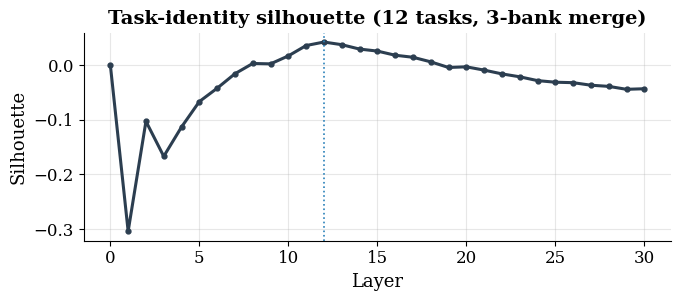

[R9.1] Task-identity silhouette peak: 0.042 @ L12
        References: paper 5-task 0.454 @ L12 | R02 8-task (2-bank) 0.121 @ L12


In [4]:
from sklearn.metrics import silhouette_score

sil_curve = np.array([silhouette_score(embeddings_np[lname], intended_task_labels)
                       for lname in SHARED_LAYERS])
PEAK_IDX   = int(np.argmax(sil_curve))
PEAK_LAYER = SHARED_LAYERS[PEAK_IDX]
PEAK_NUM   = LAYER_NUMS[PEAK_IDX]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(LAYER_NUMS, sil_curve, color='#2C3E50', marker='o', ms=3.5)
ax.axvline(PEAK_NUM, color='#2980B9', ls=':', lw=1.2)
ax.set_xlabel('Layer'); ax.set_ylabel('Silhouette')
ax.set_title(f'Task-identity silhouette ({len(ALL_TASKS)} tasks, 3-bank merge)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/r9_fig00_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'[R9.1] Task-identity silhouette peak: {sil_curve.max():.3f} @ L{PEAK_NUM}')
print(f'        References: paper 5-task 0.454 @ L12 | R02 8-task (2-bank) 0.121 @ L12')

## Analysis 2 — Per-task OR directions with every valid task (the headline)

This is the analysis JwzU's "more tasks" ask feeds directly into. Every task with OR n>=5
and HA n>=5 contributes a direction; the pairwise cosine matrix and its off-diagonal mean
extend R02's 3-task version (0.428 +/- 0.058). The fresh per-task RH alignment is recomputed
on this same merged bank (R02 policy: never compare against stale references).

Arditi directions loaded (31 layers)

Per-task OR direction eligibility:
  char_shuffle        : OR=  3  HA=183  [skipped]
  continuation        : OR=306  HA=338  [valid]
  conversational_qa   : OR=318  HA=327  [valid]
  cryptanalysis       : OR=  0  HA= 60  [skipped]
  draft_message       : OR=184  HA=459  [valid]
  keywords_identification: OR=155  HA=490  [valid]
  pos_tagging         : OR=  3  HA=183  [skipped]
  rag_qa              : OR=  0  HA= 30  [skipped]
  rephrase            : OR=  0  HA=  0  [skipped]
  sentiment_analysis  : OR= 13  HA= 34  [valid]
  translate           : OR= 18  HA= 31  [valid]
  word_shuffle        : OR=  1  HA=185  [skipped]


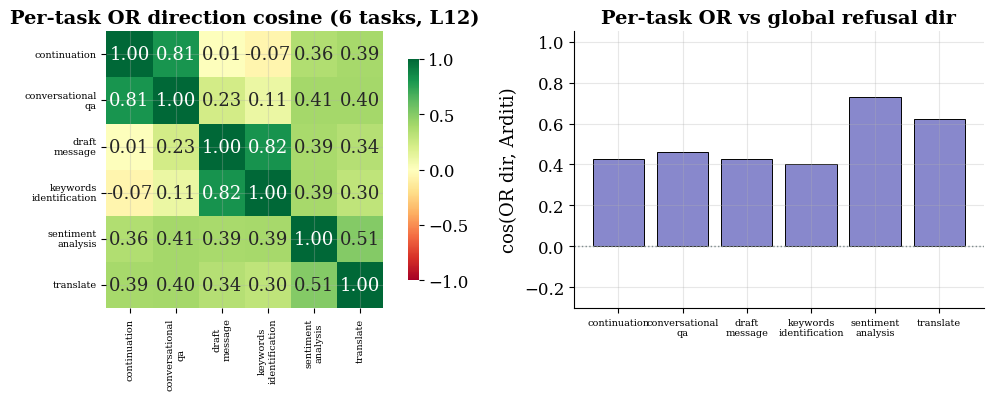

[R9.2] Valid OR tasks (n>=5): 6  (continuation, conversational_qa, draft_message, keywords_identification, sentiment_analysis, translate)   [R02: 3]
[R9.3] OR pairwise cosine (off-diag):  0.358 +/- 0.235   [R02: 0.428 +/- 0.058]
[R9.4] Fresh RH alignment (this bank, N=7: char_shuffle, continuation, conversational_qa, draft_message, keywords_identification, sentiment_analysis, translate):
        0.636 +/- 0.140   [R02: 0.536 +/- 0.086, N=4]
[R9.5] mean cos(task OR, Arditi):      0.511   [R02: 0.596]


In [5]:
candidate_dirs = torch.load('arditi_artefacts/candidate_directions.pt')
arditi_dirs = {}
for lname in SHARED_LAYERS:
    if lname in candidate_dirs:
        d = candidate_dirs[lname].numpy().astype(np.float32)
        arditi_dirs[lname] = d / (np.linalg.norm(d) + 1e-8)
print(f'Arditi directions loaded ({len(arditi_dirs)} layers)')

MIN_SAMPLES = 5
emb_peak = embeddings_np[PEAK_LAYER]

task_or_dirs, valid_tasks = {}, []
print('\nPer-task OR direction eligibility:')
for task in ALL_TASKS:
    m_or = OVER_REFUSAL_MASK & (intended_task_labels == task)
    m_ha = HARMLESS_ANSWERED & (intended_task_labels == task)
    ok = m_or.sum() >= MIN_SAMPLES and m_ha.sum() >= MIN_SAMPLES
    print(f'  {task:<20}: OR={m_or.sum():>3d}  HA={m_ha.sum():>3d}  {"[valid]" if ok else "[skipped]"}')
    if ok:
        d = emb_peak[m_or].mean(0) - emb_peak[m_ha].mean(0)
        task_or_dirs[task] = d / (np.linalg.norm(d) + 1e-8)
        valid_tasks.append(task)

N = len(valid_tasks)
sim = np.zeros((N, N))
for i, ti in enumerate(valid_tasks):
    for j, tj in enumerate(valid_tasks):
        sim[i, j] = float(np.dot(task_or_dirs[ti], task_or_dirs[tj]))
off_diag = sim[~np.eye(N, dtype=bool)] if N > 1 else np.array([np.nan])

# Fresh per-task RH alignment from THIS merged bank (same policy as R02's [R2.17])
task_rh_dirs, valid_rh_tasks = {}, []
for task in ALL_TASKS:
    m_rh = REFUSED_HARMFUL   & (intended_task_labels == task)
    m_ha = HARMLESS_ANSWERED & (intended_task_labels == task)
    if m_rh.sum() >= MIN_SAMPLES and m_ha.sum() >= MIN_SAMPLES:
        d = emb_peak[m_rh].mean(0) - emb_peak[m_ha].mean(0)
        task_rh_dirs[task] = d / (np.linalg.norm(d) + 1e-8)
        valid_rh_tasks.append(task)
N_RH = len(valid_rh_tasks)
sim_rh = np.zeros((N_RH, N_RH))
for i, ti in enumerate(valid_rh_tasks):
    for j, tj in enumerate(valid_rh_tasks):
        sim_rh[i, j] = float(np.dot(task_rh_dirs[ti], task_rh_dirs[tj]))
off_diag_rh = sim_rh[~np.eye(N_RH, dtype=bool)] if N_RH > 1 else np.array([np.nan])

cos_arditi = [float(np.dot(task_or_dirs[t], arditi_dirs[PEAK_LAYER])) for t in valid_tasks]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={'width_ratios': [1.2, 1]})
sns.heatmap(sim, ax=axes[0], cmap='RdYlGn', vmin=-1, vmax=1, annot=True, fmt='.2f',
            xticklabels=[t.replace('_', '\n') for t in valid_tasks],
            yticklabels=[t.replace('_', '\n') for t in valid_tasks],
            square=True, cbar_kws={'shrink': 0.8})
axes[0].set_title(f'Per-task OR direction cosine ({N} tasks, L{PEAK_NUM})')
axes[0].tick_params(labelsize=7)
axes[1].bar(range(N), cos_arditi, color='#8888CC', edgecolor='black', lw=0.7)
axes[1].axhline(0, color='#7F8C8D', ls=':', lw=1)
axes[1].set_xticks(range(N))
axes[1].set_xticklabels([t.replace('_', '\n') for t in valid_tasks], fontsize=7)
axes[1].set_ylabel('cos(OR dir, Arditi)'); axes[1].set_ylim(-0.3, 1.05)
axes[1].set_title('Per-task OR vs global refusal dir')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/r9_fig01_or_directions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'[R9.2] Valid OR tasks (n>={MIN_SAMPLES}): {N}  ({", ".join(valid_tasks)})   [R02: 3]')
print(f'[R9.3] OR pairwise cosine (off-diag):  {np.nanmean(off_diag):.3f} +/- {np.nanstd(off_diag):.3f}   [R02: 0.428 +/- 0.058]')
print(f'[R9.4] Fresh RH alignment (this bank, N={N_RH}: {", ".join(valid_rh_tasks)}):')
print(f'        {np.nanmean(off_diag_rh):.3f} +/- {np.nanstd(off_diag_rh):.3f}   [R02: 0.536 +/- 0.086, N=4]')
print(f'[R9.5] mean cos(task OR, Arditi):      {np.mean(cos_arditi):.3f}   [R02: 0.596]')

## Analysis 3 — Global OR direction vs Arditi direction, per layer

Same construction as R02 Analysis 3 (OR mean minus TARGET mean, TARGET from the judged
original+R01 rows). Reference line is perfect alignment at 1.0 (never the old stale
harmful-refusal band -- see R03's note on that reference).

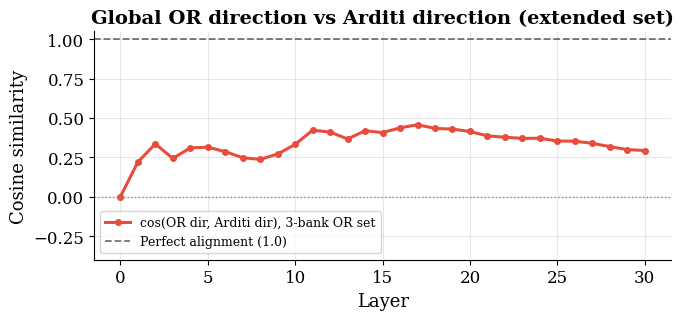

[R9.6] cos(global OR, Arditi) @ L12: +0.410   [R02: +0.464 | paper: +0.448]


In [6]:
or_cos = []
for lname in SHARED_LAYERS:
    if lname not in arditi_dirs:
        continue
    emb = embeddings_np[lname]
    d = emb[OVER_REFUSAL_MASK].mean(0) - emb[TARGET_MASK].mean(0)
    d = d / (np.linalg.norm(d) + 1e-8)
    or_cos.append((int(lname.split('_')[1]), float(np.dot(d, arditi_dirs[lname]))))
lx, ly = zip(*sorted(or_cos))

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(lx, ly, color='#E74C3C', marker='o', ms=4, label='cos(OR dir, Arditi dir), 3-bank OR set')
ax.axhline(1.0, color='#2C3E50', ls='--', lw=1.3, alpha=0.7, label='Perfect alignment (1.0)')
ax.axhline(0, color='#7F8C8D', ls=':', lw=1)
ax.set_xlabel('Layer'); ax.set_ylabel('Cosine similarity')
ax.set_ylim(-0.4, 1.05); ax.legend(fontsize=9)
ax.set_title('Global OR direction vs Arditi direction (extended set)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/r9_fig02_or_vs_arditi.png', dpi=300, bbox_inches='tight')
plt.show()

cos_at_peak = dict(or_cos).get(PEAK_NUM, float('nan'))
print(f'[R9.6] cos(global OR, Arditi) @ L{PEAK_NUM}: {cos_at_peak:+.3f}   [R02: +0.464 | paper: +0.448]')

## Analysis 4 — Matched-n dimensionality (consistency check only)

The dimensionality claim is already retracted (four independent conditions, all <=0.9%,
see the general response). This cell re-runs the pooled matched-n test on the extended set
purely for consistency: a low number is expected and confirms nothing changed; a high number
would be new information for the revision, not something to inject into the rebuttal.

In [7]:
from sklearn.decomposition import PCA

def n80_of(X):
    evr = PCA(n_components=min(X.shape), random_state=0).fit(X).explained_variance_ratio_
    return int(np.searchsorted(np.cumsum(evr), 0.80) + 1)

emb   = embeddings_np[PEAK_LAYER]
X_or  = emb[OVER_REFUSAL_MASK] - emb[TARGET_MASK].mean(0)
X_rh  = emb[REFUSED_HARMFUL]   - emb[HARMLESS_ANSWERED].mean(0)
n_min = min(len(X_or), len(X_rh))

rng = np.random.default_rng(SEED)
N_SUB = 1000
n80_or_sub = np.empty(N_SUB); n80_rh_sub = np.empty(N_SUB)
for b in range(N_SUB):
    Xo = X_or[rng.choice(len(X_or), n_min, replace=False)]
    Xr = X_rh[rng.choice(len(X_rh), n_min, replace=False)]
    n80_or_sub[b] = n80_of(Xo); n80_rh_sub[b] = n80_of(Xr)

frac_gap = float((n80_or_sub > n80_rh_sub).mean())
print(f'[R9.7] Matched-n (n={n_min}) n80: OR {np.median(n80_or_sub):.0f} vs RH {np.median(n80_rh_sub):.0f}')
print(f'[R9.8] P(n80_OR > n80_RH) at matched n: {frac_gap:.2%}   [R02/R03: 0.00-0.90%, claim retracted]')

[R9.7] Matched-n (n=270) n80: OR 17 vs RH 28
[R9.8] P(n80_OR > n80_RH) at matched n: 0.00%   [R02/R03: 0.00-0.90%, claim retracted]


In [8]:
print('=' * 78)
print('R09 CONSOLIDATED NUMBERS  (3-bank merge)          vs  R02 (2-bank, in docs now)')
print('=' * 78)
print(f'[R9.1] Task silhouette peak:        {sil_curve.max():.3f} @ L{PEAK_NUM}        (R02: 0.121 @ L12)')
print(f'[R9.2] Valid OR tasks (n>=5):       {N} ({", ".join(valid_tasks)})')
print(f'                                                       (R02: 3)')
print(f'[R9.3] OR pairwise cosine:          {np.nanmean(off_diag):.3f} +/- {np.nanstd(off_diag):.3f}      (R02: 0.428 +/- 0.058)')
print(f'[R9.4] Fresh RH alignment (N={N_RH}):   {np.nanmean(off_diag_rh):.3f} +/- {np.nanstd(off_diag_rh):.3f}      (R02: 0.536 +/- 0.086, N=4)')
print(f'[R9.5] mean cos(task OR, Arditi):   {np.mean(cos_arditi):.3f}              (R02: 0.596)')
print(f'[R9.6] cos(global OR, Arditi):      {cos_at_peak:+.3f}             (R02: +0.464)')
print(f'[R9.8] P(n80_OR > n80_RH):          {frac_gap:.2%}              (R02/R03: 0.00-0.90%, retracted)')
print('=' * 78)
print()
print('Decision guide (which numbers go in the response docs):')
print(' - [R9.2] >= 4 AND [R9.3] clearly below [R9.4]  ->  use the extended numbers in')
print('   reviewer_JwzU.md W1 and general response point 1: same conclusion, more tasks,')
print('   strictly stronger evidence. Also update the per-task OR-rate table with the new')
print('   task rows (from R08 Step 5).')
print(' - [R9.3] rises to or above [R9.4]  ->  the extended set WEAKENS the task-specificity')
print('   contrast. Do not silently keep the 3-task number while sitting on this analysis;')
print('   surface it and choose the framing honestly (scope the claim, or report both),')
print('   exactly as was done for the dimensionality retraction.')
print(' - [R9.8] is expected to stay ~0-1% (claim already retracted). If it flips high,')
print('   treat as revision material, not last-minute rebuttal material.')

R09 CONSOLIDATED NUMBERS  (3-bank merge)          vs  R02 (2-bank, in docs now)
[R9.1] Task silhouette peak:        0.042 @ L12        (R02: 0.121 @ L12)
[R9.2] Valid OR tasks (n>=5):       6 (continuation, conversational_qa, draft_message, keywords_identification, sentiment_analysis, translate)
                                                       (R02: 3)
[R9.3] OR pairwise cosine:          0.358 +/- 0.235      (R02: 0.428 +/- 0.058)
[R9.4] Fresh RH alignment (N=7):   0.636 +/- 0.140      (R02: 0.536 +/- 0.086, N=4)
[R9.5] mean cos(task OR, Arditi):   0.511              (R02: 0.596)
[R9.6] cos(global OR, Arditi):      +0.410             (R02: +0.464)
[R9.8] P(n80_OR > n80_RH):          0.00%              (R02/R03: 0.00-0.90%, retracted)

Decision guide (which numbers go in the response docs):
 - [R9.2] >= 4 AND [R9.3] clearly below [R9.4]  ->  use the extended numbers in
   reviewer_JwzU.md W1 and general response point 1: same conclusion, more tasks,
   strictly stronger evidence. 